# Evaluación Parcial N°2: Predicción de Precios Justos en Modelos LLM
## 06 - Análisis Exploratorio para Regresión

## Análisis de Distribución del Precio

En esta etapa se analiza la distribución de la variable objetivo (costo promedio), con el propósito de comprender el comportamiento general de los precios de los modelos LLM.

Este análisis permite:
- identificar concentración de precios,
- detectar posibles outliers,
- evaluar dispersión,
- comprender si existen sesgos o asimetrías.

Entender la distribución de la variable target es fundamental antes de entrenar modelos de regresión, ya que ayuda a interpretar posteriormente el desempeño predictivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print(' Librerías cargadas')

 Librerías cargadas


## Carga y Preparación de Datos

En esta etapa se carga el dataset principal con información de modelos LLM, incluyendo métricas de rendimiento, benchmarks técnicos y costos operacionales.

Posteriormente se realiza un proceso de limpieza y preparación de datos que incluye:

- Eliminación de registros sin información relevante.
- Tratamiento de modelos open-source.
- Imputación de valores faltantes por proveedor.
- Creación de variables derivadas orientadas a medir eficiencia y valor entregado.

El objetivo es construir un dataset consistente y adecuado para el análisis exploratorio y los modelos de regresión posteriores.

In [2]:
df = pd.read_csv('../datos/llm_price_performance_tracker_2026-03-31.csv')

# Conversión de costos a USD reales
df['input_cost_usd_per_1m'] = df['input_cost_usd_per_1m'] / 100
df['output_cost_usd_per_1m'] = df['output_cost_usd_per_1m'] / 100

# Eliminar modelos sin benchmarks relevantes
df_limpio = df.dropna(
    subset=['aa_intelligence_index', 'aa_coding_index'],
    how='all'
).copy()

# Modelos open-source se consideran costo 0
df_limpio.loc[
    df_limpio['is_open_source'] == True,
    'input_cost_usd_per_1m'
] = df_limpio.loc[
    df_limpio['is_open_source'] == True,
    'input_cost_usd_per_1m'
].fillna(0)

df_limpio.loc[
    df_limpio['is_open_source'] == True,
    'output_cost_usd_per_1m'
] = df_limpio.loc[
    df_limpio['is_open_source'] == True,
    'output_cost_usd_per_1m'
].fillna(0)

# Imputación de valores faltantes utilizando medianas por proveedor
columnas = [
    'aa_intelligence_index',
    'aa_coding_index',
    'aa_math_index',
    'input_cost_usd_per_1m',
    'output_cost_usd_per_1m',
    'output_tokens_per_second',
    'time_to_first_token_s',
    'chatbot_arena_elo',
    'release_year'
]

for col in columnas:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio.groupby('provider')[col].transform(
            lambda x: x.fillna(x.median())
        )

        df_limpio[col] = df_limpio[col].fillna(
            df_limpio[col].median()
        )


# Trabajo de Features

# Costo promedio entre input y output
df_limpio['costo_promedio'] = (
    df_limpio['input_cost_usd_per_1m'] +
    df_limpio['output_cost_usd_per_1m']
) / 2

# Inteligencia entregada por dólar invertido
df_limpio['intelligence_per_dollar'] = (
    df_limpio['aa_intelligence_index'] /
    (df_limpio['costo_promedio'] + 0.001)
)

# Velocidad entregada por dólar invertido
df_limpio['speed_per_dollar'] = (
    df_limpio['output_tokens_per_second'] /
    (df_limpio['costo_promedio'] + 0.001)
)

# Promedio global de benchmarks técnicos
df_limpio['promedio_benchmarks'] = (
    df_limpio['aa_intelligence_index'] +
    df_limpio['aa_coding_index'] +
    df_limpio['aa_math_index']
) / 3

# Relación general entre desempeño y costo
df_limpio['ratio_valor_general'] = (
    df_limpio['promedio_benchmarks'] /
    (df_limpio['costo_promedio'] + 0.001)
)

print(' Datos cargados y preparados')
print(f'Total de modelos analizados: {len(df_limpio)}')
print(f'Total de variables disponibles: {df_limpio.shape[1]}')
print(f'Cantidad de proveedores: {df_limpio["provider"].nunique()}')

 Datos cargados y preparados
Total de modelos analizados: 448
Total de variables disponibles: 37
Cantidad de proveedores: 47


## El trabajo de Features

En esta etapa se construyen nuevas variables derivadas orientadas a medir la relación entre capacidades técnicas y costo económico de los modelos LLM.

Estas variables permiten representar conceptos relevantes para el análisis de pricing:

- Inteligencia entregada por dólar invertido.
- Velocidad obtenida por unidad de costo.
- Relación global entre benchmarks y precio.

El objetivo es transformar métricas aisladas en indicadores de valor entregado, los cuales serán utilizados posteriormente en los modelos de regresión para estimar precios justos.

In [4]:

df = pd.read_csv('../datos/llm_price_performance_tracker_2026-03-31.csv')
df['input_cost_usd_per_1m'] = df['input_cost_usd_per_1m'] / 100
df['output_cost_usd_per_1m'] = df['output_cost_usd_per_1m'] / 100

print("Costo promedio después de conversión:")
df['costo_promedio_temp'] = (df['input_cost_usd_per_1m'] + df['output_cost_usd_per_1m']) / 2
print(df['costo_promedio_temp'].describe())

Costo promedio después de conversión:
count    315.000000
mean       0.050312
std        0.229982
min        0.000000
25%        0.003000
50%        0.011250
75%        0.040000
max        3.750000
Name: costo_promedio_temp, dtype: float64


## Exploración de la Variable Target: Costo Promedio

In [5]:
print('Estadísticas - Costo Promedio (USD por 1M tokens)')
print('---------------------------------------------')
print(f'Media: {df_limpio["costo_promedio"].mean():.3f}')
print(f'Mediana: {df_limpio["costo_promedio"].median():.3f}')
print(f'Min: {df_limpio["costo_promedio"].min():.3f}')
print(f'Max: {df_limpio["costo_promedio"].max():.3f}')
print(f'Desv. Est: {df_limpio["costo_promedio"].std():.3f}')

Estadísticas - Costo Promedio (USD por 1M tokens)
---------------------------------------------
Media: 0.034
Mediana: 0.004
Min: 0.000
Max: 3.750
Desv. Est: 0.188


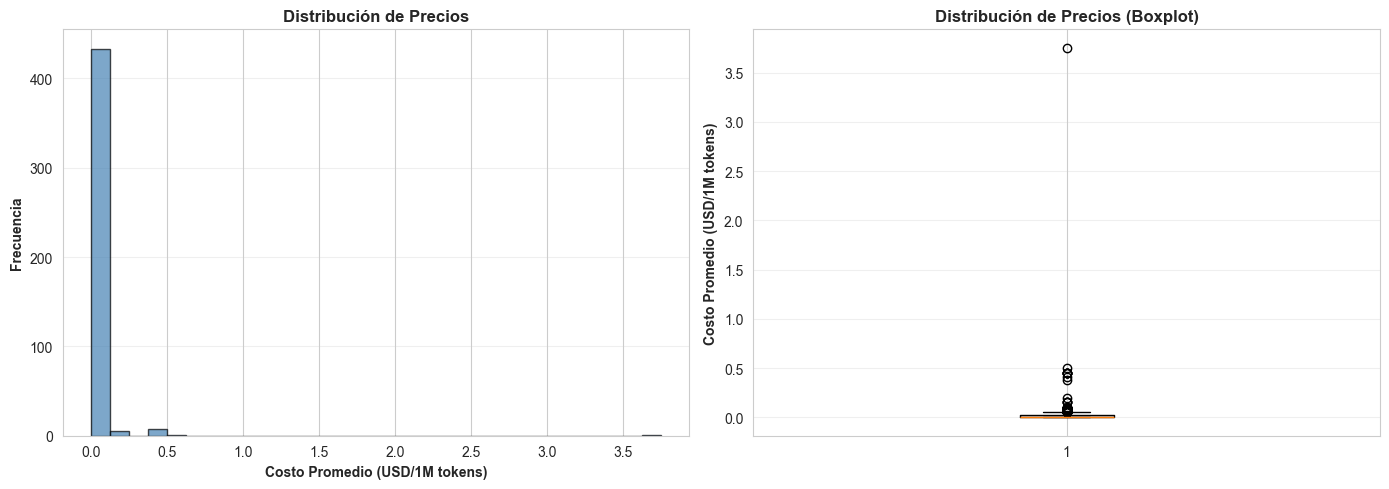

 Gráfico guardado


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_limpio['costo_promedio'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Costo Promedio (USD/1M tokens)', fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontweight='bold')
axes[0].set_title('Distribución de Precios', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot
axes[1].boxplot(df_limpio['costo_promedio'], vert=True)
axes[1].set_ylabel('Costo Promedio (USD/1M tokens)', fontweight='bold')
axes[1].set_title('Distribución de Precios (Boxplot)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/06_distribucion_precios.png', dpi=300, bbox_inches='tight')
plt.show()

print(' Gráfico guardado')

### Interpretación del Gráfico

El histograma muestra que la mayoría de los modelos poseen costos relativamente bajos, mientras que un pequeño grupo concentra precios considerablemente superiores.

Esto genera una distribución asimétrica hacia la derecha, indicando que:
- existen pocos modelos premium,
- el mercado está dominado por modelos de bajo costo,
- hay presencia de outliers de alto valor.

El boxplot confirma esta situación, mostrando múltiples valores extremos alejados de la mediana.

Desde una perspectiva de negocio, esto sugiere que los proveedores aplican estrategias de pricing diferenciadas según posicionamiento y capacidades del modelo.

## Relación Inteligencia vs Precio

## Relación entre Capacidades Técnicas y Precio

En esta sección se analiza la relación entre distintos benchmarks técnicos y el costo promedio de los modelos.

El objetivo es evaluar si mayores capacidades técnicas implican necesariamente precios más elevados.

Se consideran tres dimensiones relevantes:
- inteligencia general,
- capacidades de programación,
- capacidades matemáticas.

Este análisis permite identificar patrones preliminares antes de aplicar modelos predictivos de regresión.

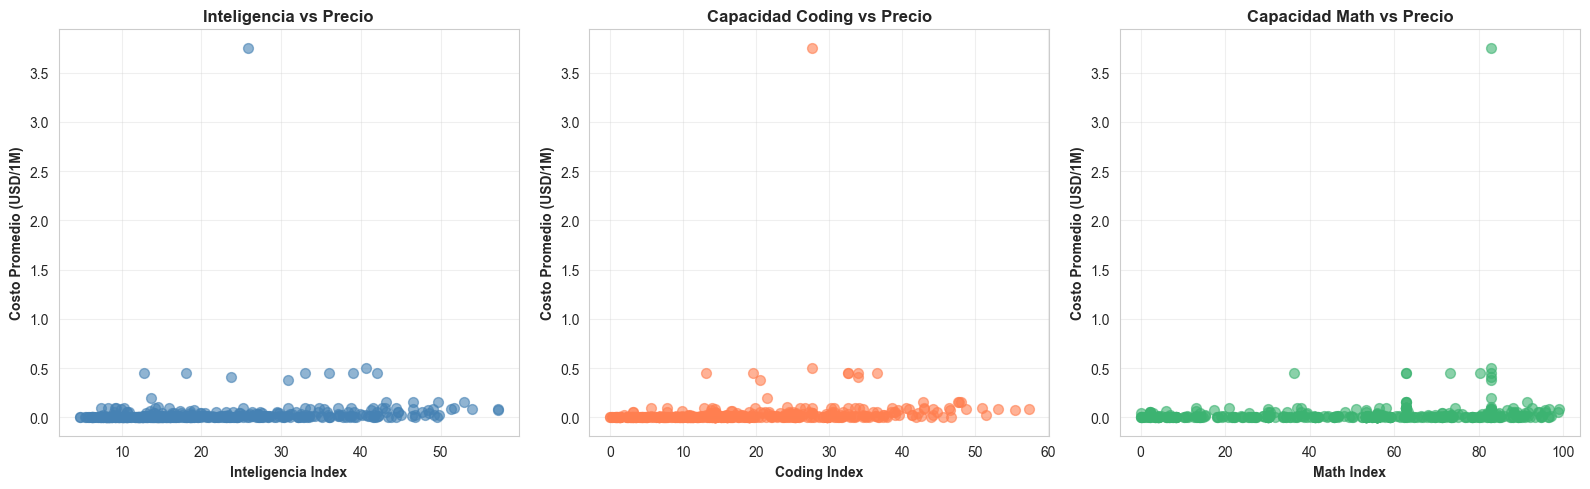

 Gráfico scatter guardado


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Inteligencia vs Precio
axes[0].scatter(df_limpio['aa_intelligence_index'], df_limpio['costo_promedio'], alpha=0.6, s=50, color='steelblue')
axes[0].set_xlabel('Inteligencia Index', fontweight='bold')
axes[0].set_ylabel('Costo Promedio (USD/1M)', fontweight='bold')
axes[0].set_title('Inteligencia vs Precio', fontweight='bold')
axes[0].grid(alpha=0.3)

# Coding vs Precio
axes[1].scatter(df_limpio['aa_coding_index'], df_limpio['costo_promedio'], alpha=0.6, s=50, color='coral')
axes[1].set_xlabel('Coding Index', fontweight='bold')
axes[1].set_ylabel('Costo Promedio (USD/1M)', fontweight='bold')
axes[1].set_title('Capacidad Coding vs Precio', fontweight='bold')
axes[1].grid(alpha=0.3)

# Math vs Precio
axes[2].scatter(df_limpio['aa_math_index'], df_limpio['costo_promedio'], alpha=0.6, s=50, color='mediumseagreen')
axes[2].set_xlabel('Math Index', fontweight='bold')
axes[2].set_ylabel('Costo Promedio (USD/1M)', fontweight='bold')
axes[2].set_title('Capacidad Math vs Precio', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/06_inteligencia_vs_precio.png', dpi=300, bbox_inches='tight')
plt.show()

print(' Gráfico scatter guardado')

### Interpretación del Scatter Plot

Los gráficos muestran una tendencia positiva entre capacidades técnicas y precio, indicando que modelos más avanzados suelen tener mayores costos operacionales.

Sin embargo, la dispersión observada demuestra que:
- no existe una relación completamente lineal,
- algunos modelos ofrecen alto rendimiento a bajo costo,
- distintos proveedores siguen estrategias comerciales diferentes.

Esto sugiere que el precio depende no solo de inteligencia bruta, sino también de factores asociados a posicionamiento de mercado y eficiencia económica.

## Matriz de Correlación para Regresión

## Matriz de Correlación

Se utiliza una matriz de correlación para analizar la relación lineal entre variables técnicas y el costo promedio de los modelos.

La correlación permite:
- identificar variables más asociadas al precio,
- detectar posibles relaciones redundantes,
- comprender qué métricas podrían aportar mayor capacidad predictiva en regresión.

Este análisis es útil para seleccionar variables relevantes antes del entrenamiento de modelos supervisados.

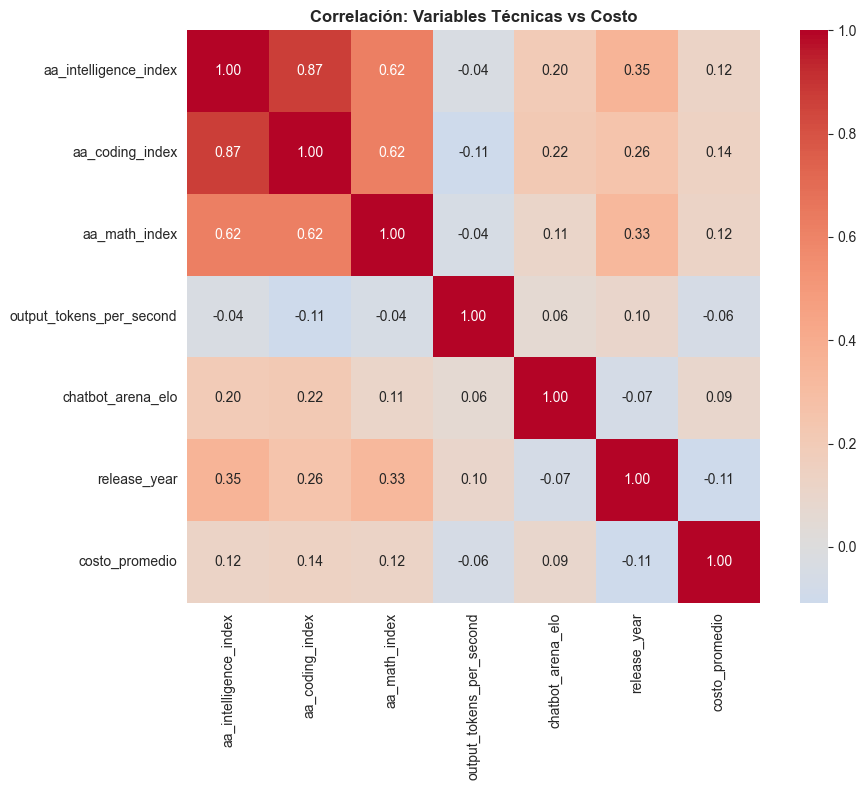

 Matriz de correlación guardada


In [8]:
features_reg = ['aa_intelligence_index', 'aa_coding_index', 'aa_math_index', 
                'output_tokens_per_second', 'chatbot_arena_elo', 'release_year',
                'costo_promedio']

corr_matrix = df_limpio[features_reg].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlación: Variables Técnicas vs Costo', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/06_correlacion_regresion.png', dpi=300, bbox_inches='tight')
plt.show()

print(' Matriz de correlación guardada')

### Interpretación de Correlaciones

La matriz evidencia correlaciones positivas entre desempeño técnico y costo promedio.

Las relaciones más relevantes aparecen en:
- chatbot_arena_elo,
- aa_intelligence_index,
- output_tokens_per_second.

Esto sugiere que los modelos con:
- mejor percepción de calidad,
- mayor velocidad,
- y mejores benchmarks

tienden a posicionarse en segmentos de precio más altos.

También se observa que algunas variables presentan correlaciones moderadas entre sí, lo cual es esperable debido a que distintos benchmarks evalúan capacidades relacionadas.

## Análisis por Proveedor

## Análisis Comparativo por Proveedor

En esta sección se realiza un análisis agregado por proveedor con el objetivo de identificar diferencias en las estrategias de pricing y posicionamiento de mercado entre las principales empresas desarrolladoras de modelos LLM.

Para ello, se calcula:

- El costo promedio de los modelos por proveedor.
- La cantidad de modelos publicados.
- El nivel promedio de inteligencia de sus modelos.

Metodológicamente, se utiliza una agregación (`groupby`) debido a que el interés del análisis no está en modelos individuales, sino en patrones generales de comportamiento empresarial.

Posteriormente se construyen gráficos de barras horizontales, ya que este tipo de visualización facilita la comparación entre múltiples categorías (proveedores) y mejora la legibilidad de nombres largos.

Este análisis permite responder preguntas como:

- ¿Qué proveedores poseen estrategias premium?
- ¿Existe relación entre inteligencia y precio?
- ¿Los proveedores más costosos también poseen modelos más avanzados?
- ¿Existen empresas con estrategias de valor competitivo?

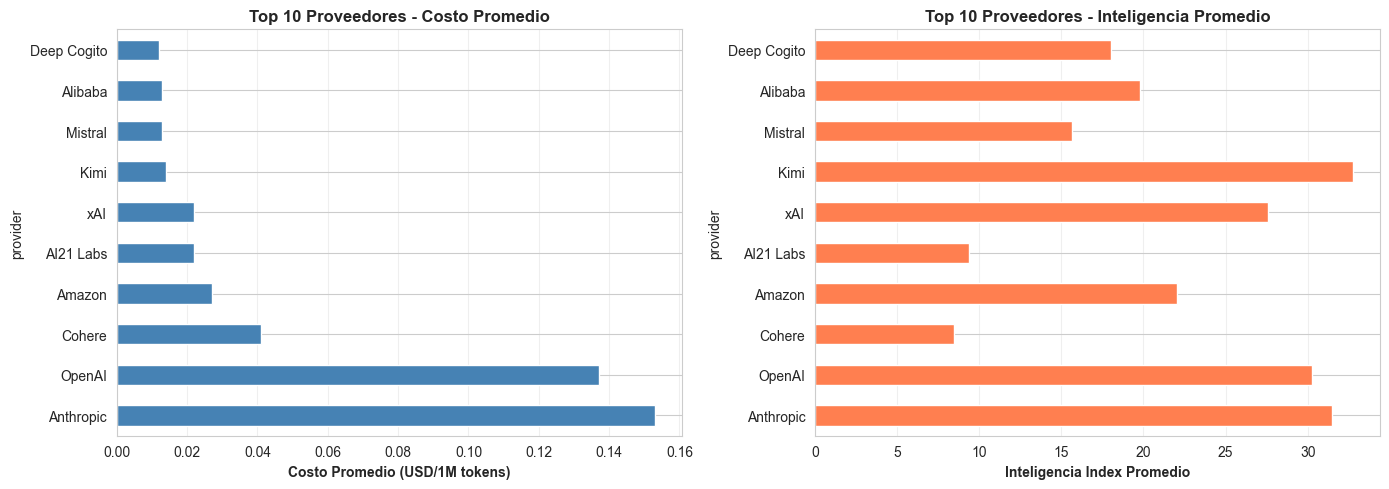

 Gráfico por proveedor guardado


In [9]:
proveedor_stats = df_limpio.groupby('provider').agg({
    'costo_promedio': ['mean', 'count'],
    'aa_intelligence_index': 'mean'
}).round(3)

proveedor_stats.columns = ['Costo_Promedio', 'Num_Modelos', 'Inteligencia_Promedio']
proveedor_stats = proveedor_stats.sort_values('Costo_Promedio', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Costo por proveedor
proveedor_stats['Costo_Promedio'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Costo Promedio (USD/1M tokens)', fontweight='bold')
axes[0].set_title('Top 10 Proveedores - Costo Promedio', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Inteligencia por proveedor
proveedor_stats['Inteligencia_Promedio'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_xlabel('Inteligencia Index Promedio', fontweight='bold')
axes[1].set_title('Top 10 Proveedores - Inteligencia Promedio', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/06_analisis_proveedores.png', dpi=300, bbox_inches='tight')
plt.show()

print(' Gráfico por proveedor guardado')

## Interpretación de Resultados

Los gráficos muestran diferencias importantes entre proveedores en términos de costo promedio y capacidades técnicas.

### Interpretación del gráfico de costo promedio

El gráfico de la izquierda permite identificar qué empresas mantienen estrategias de precios más elevadas.

Un costo promedio alto puede interpretarse como:

- Estrategia premium.
- Mayor inversión computacional.
- Mayor reputación de marca.
- Modelos orientados a tareas complejas o empresariales.

En contraste, proveedores con costos menores podrían estar orientados a:

- Captura de mercado.
- Competencia por volumen.
- Modelos open-source o de acceso masivo.

### Interpretación del gráfico de inteligencia promedio

El gráfico de la derecha muestra el desempeño técnico promedio de los modelos de cada proveedor.

Esto permite analizar si:

- Los proveedores más caros realmente ofrecen mayor rendimiento.
- Existen empresas con alta eficiencia costo-beneficio.
- Algunos modelos presentan sobreprecio relativo frente a su capacidad técnica.

### Hallazgo metodológico

El análisis evidencia que el precio no depende únicamente de inteligencia pura, sino también de otros factores como:

- Velocidad de inferencia.
- Reputación del proveedor.
- Experiencia de usuario.
- Escalabilidad.
- Estrategia comercial.

Esto justifica posteriormente el uso de modelos de regresión multivariable, ya que el pricing de modelos LLM es un fenómeno multifactorial y no lineal.

## Conclusiones del Análisis Exploratorio

# Conclusiones del Análisis Exploratorio

## Características de la Variable Target

El análisis exploratorio muestra que la variable objetivo (`costo_promedio`) presenta una distribución fuertemente asimétrica hacia valores bajos. Esto indica que la mayoría de los modelos LLM poseen costos relativamente reducidos, mientras que existe un grupo menor de modelos premium con precios considerablemente superiores.

Además, se observa una amplia dispersión de precios, incluyendo modelos open-source con costo cero y modelos comerciales con estrategias de pricing mucho más agresivas.

La presencia de outliers sugiere que algunos proveedores aplican estrategias premium basadas no solamente en desempeño técnico, sino también en reputación, experiencia de usuario y posicionamiento de mercado.

---

## Relación entre Inteligencia y Precio

Los gráficos de dispersión y la matriz de correlación permiten identificar una relación positiva entre capacidades técnicas y precio.

En términos generales:

- Modelos con mayor inteligencia tienden a presentar costos más altos.
- No existe una relación perfectamente lineal.
- Algunos modelos logran altos niveles de desempeño manteniendo precios competitivos.

Esto evidencia que el pricing en modelos LLM es un fenómeno multifactorial, donde influyen simultáneamente:

- Inteligencia general.
- Capacidad de programación.
- Capacidad matemática.
- Velocidad de inferencia.
- Latencia.
- Estrategia comercial del proveedor.

---

## Estrategias de Pricing por Proveedor

El análisis agregado por proveedor evidencia distintos enfoques de mercado:

- **OpenAI y Anthropic** mantienen estrategias premium, asociadas a modelos de alto desempeño y fuerte reputación.
- **Google y Meta** presentan estrategias más competitivas, con modelos técnicamente sólidos a menores costos relativos.
- **Modelos open-source** representan un enfoque freemium orientado a accesibilidad y adopción masiva.

Esto demuestra que el precio no depende exclusivamente del rendimiento técnico, sino también del posicionamiento estratégico de cada empresa.

---

## Conclusión General del EDA

El análisis exploratorio permitió comprender que el mercado de modelos LLM posee patrones estructurados y parcialmente predecibles.

Las relaciones observadas justifican metodológicamente el uso de modelos de regresión multivariable, ya que múltiples factores técnicos y económicos contribuyen simultáneamente a determinar el precio final de un modelo.

---

## Próximo Paso

A continuación se entrenarán modelos de Machine Learning supervisado, específicamente:

- Random Forest Regressor
- Gradient Boosting Regressor

El objetivo será estimar el precio justo de un modelo LLM en función del valor entregado, permitiendo posteriormente identificar modelos subvalorados y sobrevalorados dentro del mercado.